Objective of this notebook: Nested R hat window performance on Gaussian Mixture Distribution (for 3-4 different means and variances, perhaps)

create GMD distribution of 1,2,3,4,5 variables, each with AR(1)covariance matrix where  ρ  ∈ {0.2,0.5,0.7.0.9}
evaluate the nested r hat performance on each distribution, see where did nested r hat dropped down to 1.01
compare the nested r hat performance with regular r hat

In [ ]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

# remember to restart runtime after changing the environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.5/624.5 MB 854.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 33.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 req

In [ ]:
import numpy as np

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import matplotlib.pyplot as plt

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

[CudaDevice(id=0)]
gpu


In [ ]:
import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

Necessary Functions:

In [ ]:
#===================================
# TEST MODULE:
# check if the kernel is correctly set up
#===================================
def dist_checker(target, total_samples_short, initial_state, kernel,biject):
  result_state_short = tfp.mcmc.sample_chain(
          total_samples_short,
          initial_state,
          kernel=kernel,
          seed= random.PRNGKey(2002),
          trace_fn=None
      )
  if (biject):
    result_state_short = target.default_event_space_bijector(result_state_short)
  plt.figure(figsize=(6,6))

  for i in range(result_state_short.shape[1]):
      points = np.array(result_state_short[99:, i, :])
      plt.scatter(points[:,0], points[:,1], s=5, alpha=0.3, label=f"Chain {i}")
  if result_state_short.shape[1] <= 10:
    plt.legend()
  plt.axis("equal")
  plt.show()

# example:
# dist_checker(target, total_samples_short, initial_state, kernel_short, biject=False)

In [ ]:
#===================================
# Nested R Hat Module:
# return a list of nested R hat based on customizable window size
#+==================================
def _reduce_variance_interval(x, axis=None, biased=True, keepdims=False):
    # ddof=0 is biased variance (N), ddof=1 is unbiased variance (N-1)
    ddof = 0 if biased else 1
    return jnp.var(x, axis=axis, ddof=ddof, keepdims=keepdims)


def nested_rhat_interval(result_state, num_super_chains,window_size, idx):
  # calculate the nested rhat with "slices" of samples
  num_samples = list(range(0, 1101, window_size))
  nested_rhat_list = []
  for start, end in zip(num_samples[:-1], num_samples[1:]):
    result_state_short = result_state[start:end, :, :]
    # print(f"currently taking samples [{start}:{end}]")
    used_samples = result_state_short.shape[0]
    num_sub_chains = result_state_short.shape[1] // num_super_chains
    num_dimensions = result_state_short.shape[2]

    chain_states = result_state_short.reshape(used_samples, -1, num_sub_chains, num_dimensions)

    mean_chain = jnp.mean(chain_states, axis=0) # estimator from one subchain
    mean_super_chain = jnp.mean(chain_states, axis=(0, 2))  # estimator from one super chain

    variance_chain = _reduce_variance_interval(chain_states, axis=0, biased=False)
    variance_super_chain = _reduce_variance_interval(mean_chain, axis=1, biased=False) \
                           + jnp.mean(variance_chain, axis=1)
                           # sum of variance of mean of one chain (B_k)
                           # and mean of variance of one chain (W_k)

    W = jnp.mean(variance_super_chain, axis=0) # avg of (B_k + W_k)
    B = _reduce_variance_interval(mean_super_chain, axis=0, biased=False) # variance of between super chain

    r_hat = jnp.sqrt((W + B) / W)[idx]
    nested_rhat_list.append(float(r_hat))
  return nested_rhat_list
#===================================
# R Hat Module:
# return a list of R hat based on customizable window size
#+==================================
def compute_rhat(result_state, num_samples, num_warmup = 0):
  return tfp.mcmc.potential_scale_reduction(result_state[num_warmup:num_warmup + num_samples + 1],
                                          independent_chain_ndims = 1).T


def mc_est_warm(x, axis = 0):
  """ compute running average without discarding half of the samples."""
  return np.cumsum(x, axis) / np.arange(1, x.shape[0] + 1).reshape([-1] + [1] * (len(x.shape) - 1))


def MCMC_error(result_state, target, window_size, num_warmup,idx):
  try:
    mean_est = target.mean()
    # print(f'estimated mean is {mean_est}')
  except:
    print('no ground truth mean')
    mean_est = (result_state[num_warmup:, :]).mean(0).mean(0)
  # try:
  #   var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
  # except:
  #   print('no ground truth std dev')
  #   var_est = ((result_state[num_warmup:, :]**2).mean(0).mean(0) -
  #              mean_est**2)
  num_samples = list(range(0, 1101, window_size))
  mc_est_list = []
  for start, end in zip(num_samples[:-1], num_samples[1:]):
    result_state_short = result_state[start:end, :, :]
    # print(f"currently taking samples [{start}:{end}]")
    mc_est = mc_est_warm(result_state_short[num_warmup:, :, :].mean(1)) - mean_est
    mc_est_list.append(float(abs(mc_est[-1,idx])))
  return mc_est_list

#===================================
# R Hat Evaluation Module:
# return a dataframe of nested R hat and traditional R hat
# based on customizable window size
# based on the problem it seems like we need to discard the warmup samples
# for traditional rhat computation, but really?
#+==================================
def rhat_assess(num_simulations,window_size, total_samples_short,
                initial_state,kernel,num_super_chains,idx, biject=False):
  num_samples = list(range(0, 1101, window_size))
  range_iter = list(range(100, total_samples_short+1, window_size))
  interval_names = [
      f"{start}_{end}"
      for start, end in zip(num_samples[:-1], num_samples[1:])
      ]
  nested_rhat = []
  rhat_list = []
  trace_list = []
  mc_est_list = []
  base_key = random.PRNGKey(0)
  keys = random.split(base_key, num_simulations)
  for sim in range(num_simulations):
    rhat_short = np.empty(len(range_iter))
    result_state_short,trace = tfp.mcmc.sample_chain(
        total_samples_short,
        initial_state,
        kernel=kernel,
        seed=keys[sim],
        trace_fn=lambda _, kr: (
            kr.new_step_size,
            kr.inner_results.max_trajectory_length,
            kr.inner_results.inner_results.log_accept_ratio,
            kr.inner_results.inner_results.is_accepted
          )
        )
    step_size, traj_length, log_accept_ratio, accepted = trace

    # print(result_state_short.shape)

    trace_df = pd.DataFrame({
      "simulation": sim,
      "iteration": np.arange(total_samples_short),
      "step_size": np.asarray(step_size),
      "trajectory_length": np.asarray(traj_length),
      "accept_rate": np.mean(np.asarray(accepted), axis=1),
      "mean_log_accept_ratio": np.mean(np.asarray(log_accept_ratio), axis=1),
      "sd_log_accept_ratio": np.std(np.asarray(log_accept_ratio), axis=1),
      })

    trace_list.append(trace_df)


    if (biject):
      result_state_short = target.default_event_space_bijector(result_state_short)

    nested_val = nested_rhat_interval(result_state_short, num_super_chains,
                                      window_size,idx)
    mc_est = MCMC_error(result_state_short, target, window_size, 0,idx)
    for j,n in enumerate(range_iter):
      rhat_short[j] = compute_rhat(result_state_short, n, 100)[0]

    nested_rhat.append(nested_val)
    mc_est_list.append(mc_est)
    rhat_list.append(rhat_short)
    # Clean Up:
    jax.block_until_ready(result_state_short)

    del result_state_short
    del rhat_short
    del nested_val
    if sim % 10 == 0:
      gc.collect()

  trace_df = pd.concat(trace_list, ignore_index=True)
  nested_df = pd.DataFrame(nested_rhat, columns=interval_names)
  rhat_df = pd.DataFrame(rhat_list, columns=range_iter)
  mcErr_df = pd.DataFrame(mc_est_list, columns=interval_names)

  return nested_df, rhat_df, trace_df, mcErr_df

In [ ]:
#===================================
# GMM Module:
# return the target Gaussian Mixture distribution, kernel for sampling such
# distribution, initial state and total number of samples
#+==================================
def GMMBuilder(means,
    rho,
    num_superChain,
    num_subChain,
    weights=None,
    covs=None):
  means = jnp.array(means)

  num_components = means.shape[0]
  num_dim = means.shape[1]

  weights = (
      jnp.ones(num_components) / num_components
      if weights is None
      else jnp.array(weights)
  )
  cov = jnp.array([
    [rho ** abs(i - j) for j in range(num_dim)]
    for i in range(num_dim)
    ])
  covs = (
      jnp.stack([cov] * num_components)
      if covs is None
      else jnp.array(covs)
  )

  def target_log_prob_fn(x):
    return target.log_prob(x)
  def initialize(shape, key=random.PRNGKey(123), init_range=15.0):
    return random.uniform(
        key,
        shape + (num_dim,),
        minval=-init_range,
        maxval=init_range
    )

  target = tfd.MixtureSameFamily(
    mixture_distribution=tfd.Categorical(probs=weights),
    components_distribution=tfd.MultivariateNormalFullCovariance(
        loc=means,
        covariance_matrix=covs
    )
  )
  init_step_size = 0.5
  num_warmup_short, num_sampling_short = 100, 1000
  total_samples_short = num_warmup_short + num_sampling_short

  kernel_short = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn,init_step_size,1)
  kernel_short = tfp.experimental.mcmc.GradientBasedTrajectoryLengthAdaptation(kernel_short,num_warmup_short)
  kernel_short = tfp.mcmc.DualAveragingStepSizeAdaptation(
      kernel_short,
      num_warmup_short,
      target_accept_prob=0.75,
      reduce_fn=tfp.math.reduce_log_harmonic_mean_exp)

  initial_state = initialize((num_superChain,))
  initial_state = np.repeat(
      initial_state,
      num_subChain,
      axis=0
  )
  return target, kernel_short, initial_state, total_samples_short

In [ ]:
#===================================
# Plotting Module: obtain the plots, just plots??
# input: two dataframes, one for nested rhat and one for regular rhat
# this module should output the mean of r hat and nested r hat for every interval,
# and compare the trend
#===================================
def mean_compare(df_nested, df_rhat,plot=False):

    threshold = 1.01
    nested_mean = df_nested.mean()
    rhat_mean = df_rhat.mean()

    nested_x = [int(c.split('_')[1]) for c in df_nested.columns]
    rhat_x = list(df_rhat.columns)

    nested_idx = np.where(nested_mean.values <= threshold)[0]
    if len(nested_idx) > 0:
      nested_cross = nested_x[nested_idx[0]]
    else:
      print(f"Nested R hat not converged, the least mean nested R hat value is {min(nested_mean.values)}")
      nested_cross = -1

    rhat_idx = np.where(rhat_mean.values <= threshold)[0]
    if len(rhat_idx) > 0:
      rhat_cross = rhat_x[rhat_idx[0]]
    else:
      print(f"R hat not converged, the least mean R hat value is {min(rhat_mean.values)}")
      rhat_cross = -1

    if plot:
      fig, ax = plt.subplots(figsize=(20, 9))
      ax.plot(
          nested_x,
          nested_mean.values,
          marker='o',
          label='Nested R-hat'
      )
      ax.plot(
          rhat_x,
          rhat_mean.values,
          marker='s',
          label='R-hat'
      )

      if len(nested_idx) > 0:
          ax.axvline(
              nested_cross,
              color='C0',
              linestyle=':',
              alpha=0.8,
              label=f'Nested ≤ {threshold} ({nested_cross})'
          )

      if len(rhat_idx) > 0:
          ax.axvline(
              rhat_cross,
              color='C1',
              linestyle=':',
              alpha=0.8,
              label=f'R-hat ≤ {threshold} ({rhat_cross})'
          )

      ax.axhline(threshold, color='red', linestyle='--')

      ax.set_xlabel('Number of samples')
      ax.set_ylabel('Mean diagnostic value')
      ax.set_title('Nested R-hat vs R-hat')
      ax.legend()

      plt.show()
    return nested_cross, rhat_cross
# example:
# mean_compare(df_nested, df_rhat)

In [ ]:
# simulation module:
means_list = [
    [
        [0., 0.],
        [8., 0.]
    ],
    [
        [0., 0.],
        [8., 0.],
        [-10,  0]
    ],
    [
        [0., 0.],
        [8., 0.],
        [-3,  0],
        [-12, 0]
    ],
    [
        [0., 0.],
        [8., 0.],
        [-3,  0],
        [-5, 0],
        [13, 0]
    ]

]
rho_list = [0.2,0.5,0.7,0.9]
# dim_list = [2]
# rho_list = [0.2]
num_simulations = 100
window_size = 20

for means in means_list:
  for rho in rho_list:
    mem(f"Simulation: Modes:{len(means)}, rho:{rho} - start")
    num_superChain = 4
    num_subChain = 128

    target,kernel,initial_state, total_samples = GMMBuilder(means,rho,num_superChain,num_subChain)
    df_nested, df_rhat = rhat_assess(num_simulations,window_size,
                                     total_samples, initial_state,
                                     kernel, num_superChain,0)
    nested_idx, rhat_idx = mean_compare(df_nested, df_rhat, plot=False)
    print(f"Modes:{len(means)}, rho: {rho}, nested_idx: {nested_idx}, rhat_idx: {rhat_idx}")
    # stub for dataframe construction
    del target
    del kernel
    del initial_state
    del df_nested
    del df_rhat

    gc.collect()
    jax.clear_caches()

Simulation: Modes:2, rho:0.2 - start: 1245.6 MB
Nested R hat not converged, the least mean nested R hat value is 1.6869151318073272

R hat not converged, the least mean R hat value is 14.978192081451416

Modes:2, rho: 0.2, nested_idx: -1, rhat_idx: -1
Simulation: Modes:2, rho:0.5 - start: 3246.5 MB
Nested R hat not converged, the least mean nested R hat value is 1.719552801847458

R hat not converged, the least mean R hat value is 16.57273663520813

Modes:2, rho: 0.5, nested_idx: -1, rhat_idx: -1
Simulation: Modes:2, rho:0.7 - start: 3251.5 MB
Nested R hat not converged, the least mean nested R hat value is 2.8521868658065794

R hat not converged, the least mean R hat value is 16.46476845741272

Modes:2, rho: 0.7, nested_idx: -1, rhat_idx: -1
Simulation: Modes:2, rho:0.9 - start: 3251.8 MB
Nested R hat not converged, the least mean nested R hat value is 2.985043420791626

R hat not converged, the least mean R hat value is 14.00692551612854

Modes:2, rho: 0.9, nested_idx: -1, rhat_idx: 

Simulation: Modes:2, rho:0.2 - start: 2155.0 MB
(1100, 512, 2)
no ground truth mean
Nested R hat not converged, the least mean nested R hat value is 1.6889368295669556
R hat not converged, the least mean R hat value is 14.833274841308594


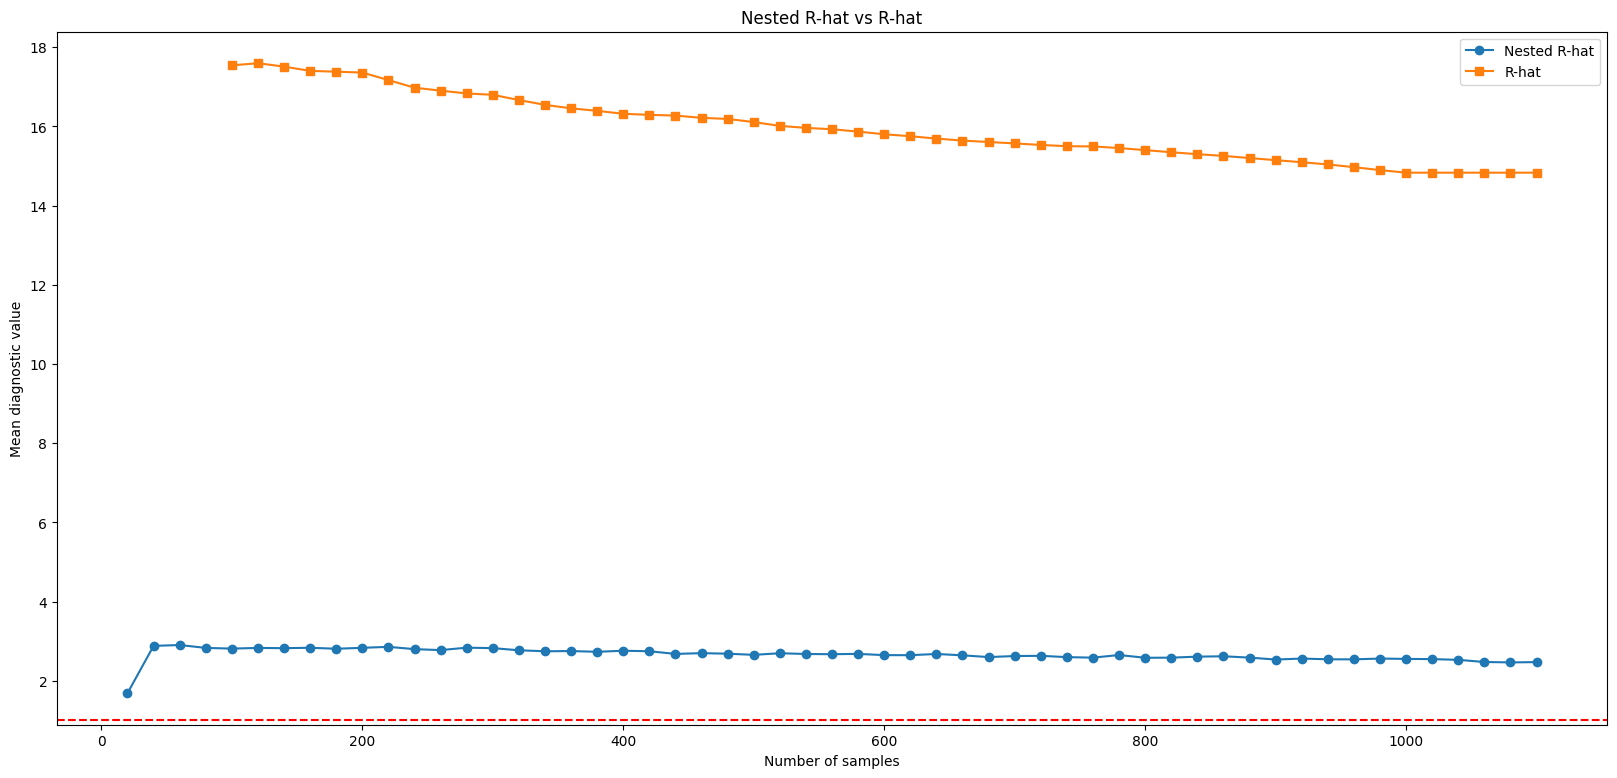

Modes:2, rho: 0.2, nested_idx: -1, rhat_idx: -1


'\nSimulation: Modes:2, rho:0.2 - start: 3251.3 MB\nNested R hat not converged, the least mean nested R hat value is 1.6869151318073272\n\nR hat not converged, the least mean R hat value is 14.978192081451416\n'

In [ ]:
# simulation module:
means_list = [
    [
        [0., 0.],
        [8., 0.]
    ]
]

rho_list = [0.2]
num_simulations = 1
window_size = 20

for means in means_list:
  for rho in rho_list:
    mem(f"Simulation: Modes:{len(means)}, rho:{rho} - start")
    num_superChain = 4
    num_subChain = 128

    target,kernel,initial_state, total_samples = GMMBuilder(means,rho,num_superChain,num_subChain)
    df_nested, df_rhat, df_trace, df_mc = rhat_assess(num_simulations,window_size,
                                     total_samples, initial_state,
                                     kernel, num_superChain,0)

    nested_idx, rhat_idx = mean_compare(df_nested, df_rhat, plot=True)
    print(f"Modes:{len(means)}, rho: {rho}, nested_idx: {nested_idx}, rhat_idx: {rhat_idx}")
    # stub for dataframe construction
    del target
    del kernel
    del initial_state
    # del df_nested
    # del df_rhat
    # del df_trace
    # del df_mc

    gc.collect()
    jax.clear_caches()

'''
Simulation: Modes:2, rho:0.2 - start: 3251.3 MB
Nested R hat not converged, the least mean nested R hat value is 1.6869151318073272

R hat not converged, the least mean R hat value is 14.978192081451416
'''

In [ ]:
print(df_mc.head())

       0_20     20_40     40_60     60_80    80_100   100_120   120_140  \
0 -0.678675 -0.031135 -0.009331 -0.006285  0.038501  0.027251  0.040217   

    140_160   160_180   180_200  ...   900_920   920_940   940_960   960_980  \
0  0.090803  0.000051  0.031037  ... -0.022204 -0.025558  0.060621  0.012328   

   980_1000  1000_1020  1020_1040  1040_1060  1060_1080  1080_1100  
0  0.007361  -0.018158  -0.028193  -0.023098  -0.029271  -0.004912  

[1 rows x 55 columns]


In [ ]:
df_nested.head()



,0_20,20_40,40_60,60_80,80_100,100_120,120_140,140_160,160_180,180_200,...,900_920,920_940,940_960,960_980,980_1000,1000_1020,1020_1040,1040_1060,1060_1080,1080_1100
0,1.688937,2.884219,2.905801,2.833574,2.815528,2.832634,2.826593,2.836883,2.811945,2.835385,...,2.564204,2.545542,2.544158,2.564128,2.55559,2.550323,2.531645,2.477453,2.467074,2.474927


In [ ]:
df_rhat.head()

,100,120,140,160,180,200,220,240,260,280,...,920,940,960,980,1000,1020,1040,1060,1080,1100
0,17.543953,17.597191,17.511734,17.404562,17.383108,17.361307,17.171759,16.978966,16.904636,16.834038,...,15.097484,15.041254,14.972588,14.898689,14.833275,14.833275,14.833275,14.833275,14.833275,14.833275
1,16.886869,16.710003,16.508373,16.385218,16.365669,16.368967,16.398699,16.379307,16.379747,16.405643,...,15.128442,15.036175,14.936924,14.851370,14.784179,14.784179,14.784179,14.784179,14.784179,14.784179
2,17.560051,17.365381,16.997904,16.846806,16.802355,16.734644,16.700823,16.682999,16.698328,16.697580,...,15.726415,15.714491,15.672818,15.631601,15.568383,15.568383,15.568383,15.568383,15.568383,15.568383
3,17.133347,16.873550,16.648893,16.521749,16.452530,16.406281,16.413383,16.452404,16.464973,16.462584,...,15.308958,15.320532,15.326716,15.336615,15.338799,15.338799,15.338799,15.338799,15.338799,15.338799
4,17.303938,17.159840,17.064518,16.971762,16.976871,16.997166,17.000496,16.981836,17.037422,17.086327,...,15.334336,15.300669,15.198610,15.098693,15.004715,15.004715,15.004715,15.004715,15.004715,15.004715


What if we make two modes close to each other?

Simulation: Modes:2, rho:0.2 - start: 3343.9 MB


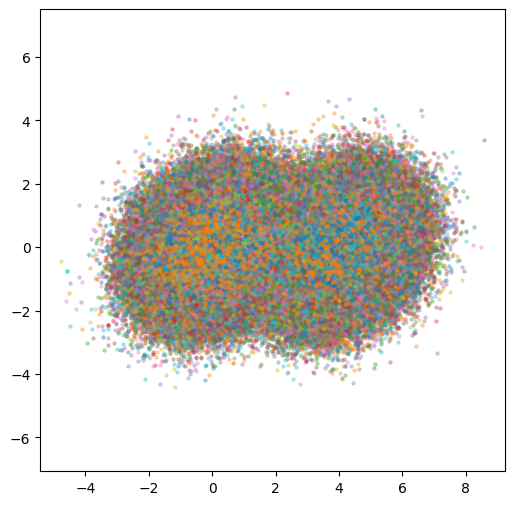

In [ ]:
# simulation module:
means_list = [
    [
        [0., 0.],
        [4., 0.]
    ]
]

rho_list = [0.2]
num_simulations = 100
window_size = 20

for means in means_list:
  for rho in rho_list:
    mem(f"Simulation: Modes:{len(means)}, rho:{rho} - start")
    num_superChain = 4
    num_subChain = 128

    target,kernel,initial_state, total_samples = GMMBuilder(means,rho,num_superChain,num_subChain)
    df_nested, df_rhat,df_trace,df_mc = rhat_assess(num_simulations,window_size,
                                     total_samples, initial_state,
                                     kernel, num_superChain,0)
    dist_checker(target, total_samples, initial_state, kernel, biject=False)
    # nested_idx, rhat_idx = mean_compare(df_nested, df_rhat, plot=True)
    # print(f"Modes:{len(means)}, rho: {rho}, nested_idx: {nested_idx}, rhat_idx: {rhat_idx}")
    # stub for dataframe construction
    # print(df_nested.head())
    # print(df_rhat.head())
    jax.clear_caches()

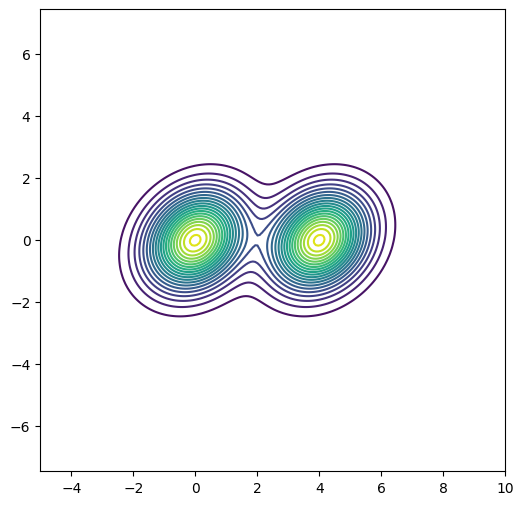

In [ ]:
# the actual counour plot:
x = np.linspace(-5, 10, 200)
y = np.linspace(-6, 6, 200)

X, Y = np.meshgrid(x, y)

XY = jnp.stack(
    [X.ravel(), Y.ravel()],
    axis=-1
)
Z = target.log_prob(XY)
Z = np.exp(np.array(Z)).reshape(X.shape)
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=20)
plt.axis("equal")
plt.show()

In [ ]:
df_nested.head()

,0_20,20_40,40_60,60_80,80_100,100_120,120_140,140_160,160_180,180_200,...,900_920,920_940,940_960,960_980,980_1000,1000_1020,1020_1040,1040_1060,1060_1080,1080_1100
0,1.180215,1.119064,1.042277,1.018657,1.003013,1.002578,1.001302,1.001139,1.000831,1.001567,...,1.001674,1.001264,1.000814,1.000927,1.000113,1.000355,1.001603,1.002132,1.003833,1.001365
1,1.202153,1.124856,1.017866,1.006713,1.004206,1.003461,1.001735,1.002984,1.002285,1.003620,...,1.004447,1.002940,1.001234,1.001426,1.004022,1.006405,1.001057,1.001172,1.001692,1.001938
2,1.177004,1.088083,1.045692,1.021904,1.002466,1.002230,1.002959,1.001378,1.002036,1.000225,...,1.004533,1.006161,1.002991,1.004565,1.003277,1.001422,1.002637,1.003570,1.001768,1.004184
3,1.236321,1.125023,1.029364,1.010306,1.007169,1.002559,1.002316,1.001082,1.003084,1.001877,...,1.006566,1.009342,1.004975,1.002224,1.001244,1.004304,1.002410,1.004075,1.000565,1.004654
4,1.165980,1.100670,1.043443,1.013748,1.004064,1.006799,1.003089,1.005782,1.004257,1.005929,...,1.000867,1.001131,1.001346,1.000434,1.001130,1.000643,1.001250,1.005753,1.002158,1.003995


In [ ]:
df_rhat.head()

,100,120,140,160,180,200,220,240,260,280,...,920,940,960,980,1000,1020,1040,1060,1080,1100
0,1.616978,1.511115,1.441933,1.397146,1.352630,1.313121,1.279018,1.243947,1.218846,1.201844,...,1.058806,1.057695,1.056829,1.055488,1.054684,1.054684,1.054684,1.054684,1.054684,1.054684
1,1.651606,1.569921,1.500364,1.449376,1.407796,1.360970,1.322262,1.292661,1.266098,1.241994,...,1.069600,1.068159,1.066929,1.066044,1.065141,1.065141,1.065141,1.065141,1.065141,1.065141
2,1.609013,1.482046,1.402933,1.356686,1.320200,1.288401,1.260919,1.238923,1.218317,1.198739,...,1.059459,1.057883,1.056092,1.055304,1.054530,1.054530,1.054530,1.054530,1.054530,1.054530
3,1.692856,1.580264,1.503680,1.440348,1.383964,1.341539,1.306811,1.283056,1.259387,1.238786,...,1.072724,1.070730,1.068707,1.067438,1.066151,1.066151,1.066151,1.066151,1.066151,1.066151
4,1.624354,1.523129,1.448874,1.390386,1.346599,1.313746,1.289193,1.273459,1.257807,1.246481,...,1.063879,1.062414,1.061195,1.059945,1.058684,1.058684,1.058684,1.058684,1.058684,1.058684


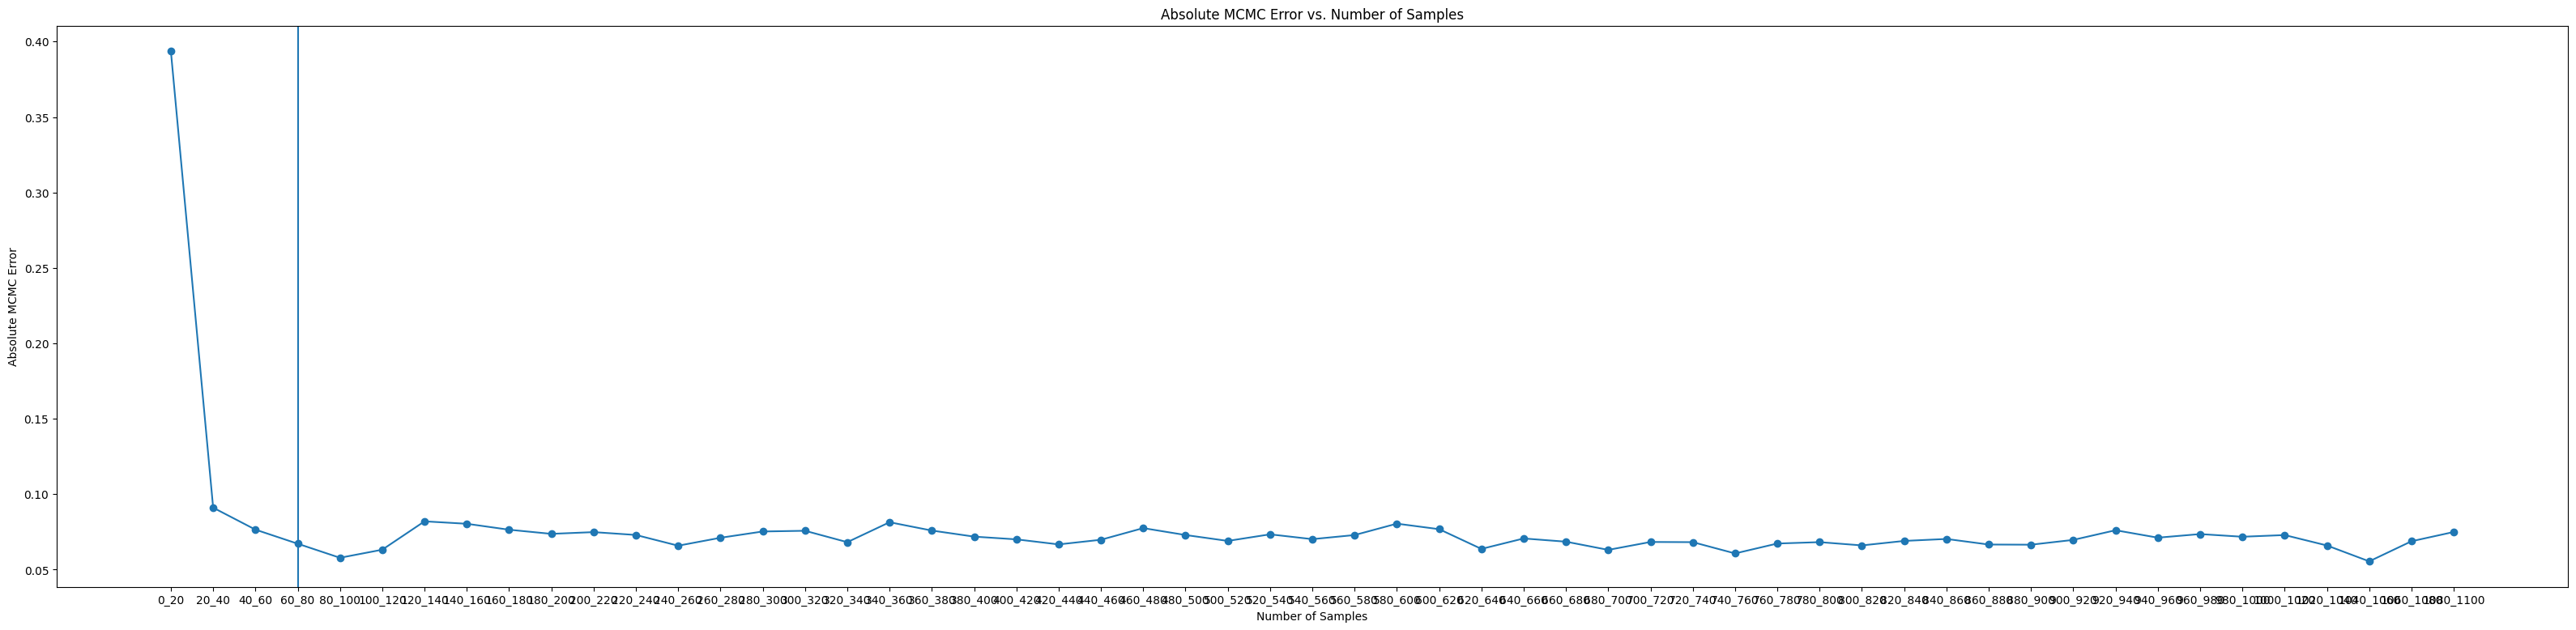

In [ ]:
figsize = (40, 9)
plt.figure(figsize=figsize)
plt.plot(df_mc.mean(),marker="o")
plt.axvline("60_80")
plt.title("Absolute MCMC Error vs. Number of Samples")
plt.xlabel("Number of Samples")
plt.ylabel("Absolute MCMC Error")
plt.show()

<Figure size 800x400 with 0 Axes>

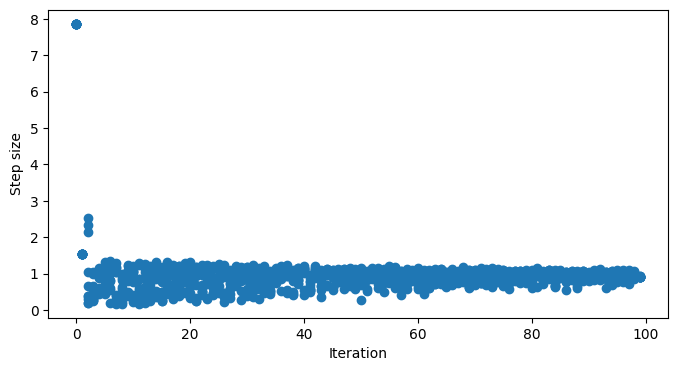

In [ ]:
plt.figure(figsize=(8,4))
warmup = df_trace[(df_trace["iteration"] < 100) & (df_trace["simulation"] <10)]

plt.figure(figsize=(8,4))
plt.scatter(warmup["iteration"], warmup["step_size"],marker='o')
plt.xlabel("Iteration")
plt.ylabel("Step size")
plt.show()

# print(warmup["step_size"].head(20))
# print(warmup["step_size"].tail(20))

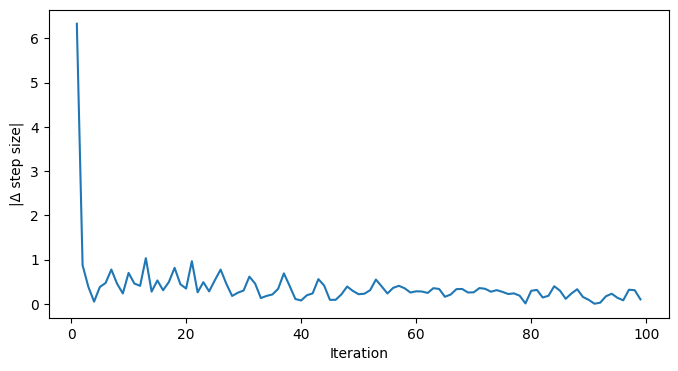

In [ ]:
warmup = df_trace[
    (df_trace["simulation"] == 0) &
    (df_trace["iteration"] < 100)
].copy()

warmup["step_change"] = warmup["step_size"].diff().abs()

plt.figure(figsize=(8,4))
plt.plot(warmup["iteration"], warmup["step_change"])
plt.xlabel("Iteration")
plt.ylabel("|Δ step size|")
plt.show()

remaining questions:  
Will it behave better if the modes are very close to each other?  
Check the estimated mean and see how it evolved.  
